# 03 — Qwen-Drive side-car (Phase 1: single perceptron)

**This notebook is the Phase-1 test bench.** The host line is Qwen-Drive-1.0-4B
(Qwen3.5-4B VLM); the side-car line is `ewm-state-machine` called through the
`ewm-scene` helper. One perceptron — the perception-token stream — runs the
loop per camera frame:

```text
perception tokens (f32 vectors, per frame t)
   │  shared codebook (mirrors ewm_app::CodebookEncoder)
   ▼
tid ids → ewm-scene → S(t), H(t-1), D/R/N, ring (BoolWindow)
   │
   ▼
ordered materialize → restored_ids → host planner/decoder → actions
```

The two scores:

- **loop accuracy** — hash-level restoration, expected **1.0**;
- **decode quality** — a driving-relevant metric (waypoint ADE), separate.

The trajectory is the per-frame BSS weight vector against the ring basis
(**soft key**), its step lengths and jump detector, cross-checked with the
Boolean-ring residual (linear novelty) and D/R/N.


*(Updated with basis frames: time travel — the last frame re-read through the first interpretation, with the spill as the travel error.)*

In [1]:
# ── 0. Environment check ─────────────────────────────────────────────────────
# This notebook needs the `ewm-nanolm` kernel (torch 2.6 + transformers 5.16 +
# the qwen_drive package). If anything is missing, switch the kernel to
# "Python 3 (ewm-nanolm)".
import sys

print("python:", sys.executable)
MISSING = []
for mod in ["numpy", "torch", "PIL", "matplotlib", "pyarrow", "qwen_drive"]:
    try:
        __import__(mod)
    except ImportError:
        MISSING.append(mod)
if MISSING:
    print("MISSING:", MISSING)
    print("recommended: Kernel -> Change Kernel -> Python (ewm-nanolm)")
else:
    print("all dependencies present")


python: /home/alexmy/.conda/envs/ewm-nanolm/bin/python
all dependencies present


In [2]:
import os, json, subprocess, time
import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_SCENE_BIN = os.path.join(EWM_SM, "target/debug/ewm-scene")
SNAP = "/home/alexmy/.cache/huggingface/hub/models--Qwen--Qwen-Drive-1.0-4B/snapshots/28484089a7cc8c335cf5089fb0745cf7c49b6eaa"
DEMO = "/home/alexmy/.cache/ewm-qwendrive/demo"
WORK = "/home/alexmy/.cache/ewm-qwendrive/work"
os.makedirs(WORK, exist_ok=True)

# Build the direct-morphisms helper if it is not there yet.
if not os.path.exists(EWM_SCENE_BIN):
    print("building ewm-scene (first time) ...", flush=True)
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"],
                   cwd=EWM_SM, check=True)
    print("built", EWM_SCENE_BIN)
else:
    print("ewm-scene binary present:", EWM_SCENE_BIN)


def ewm_scene(*args):
    r = subprocess.run([EWM_SCENE_BIN, *args], capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-scene failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())


print("ewm-state-machine:", EWM_SM)
print("Qwen-Drive snapshot:", SNAP)
print("demo data:", DEMO)


ewm-scene binary present: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
ewm-state-machine: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine
Qwen-Drive snapshot: /home/alexmy/.cache/huggingface/hub/models--Qwen--Qwen-Drive-1.0-4B/snapshots/28484089a7cc8c335cf5089fb0745cf7c49b6eaa
demo data: /home/alexmy/.cache/ewm-qwendrive/demo


---
## Host line — Qwen-Drive perception tokens

Qwen-Drive-1.0 keeps the Qwen3.5 VLM architecture untouched and attaches a BEV
perception head and a Planning Expert. We tap the **shared VLM representations**:
for each camera frame we run the VLM forward and take the last-layer hidden
states at the visual-token positions — the continuous latent embeddings of the
scene. Those are the *perception tokens* the side-car consumes.

The 12-frame planning scene does not fit a 12 GB card under SDPA (no
flash-attn), so frames are extracted one at a time with the history pixel
budget. The side-car loop then runs **per frame/turn** (12 frames per scene).


In [3]:
import torch
from qwen_drive import QwenDriveForPlanning

MODEL_ID = "Qwen/Qwen-Drive-1.0-4B"
ENC_CACHE = f"{WORK}/perception_encodings.npy"

if os.path.exists(ENC_CACHE):
    print("perception tokens already cached; skipping the VLM load")
    model = None
else:
    print("loading Qwen-Drive VLM (no planner for extraction) ...", flush=True)
    t0 = time.time()
    model = QwenDriveForPlanning.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        attn_implementation="sdpa",
    ).eval().cuda()
    print(f"loaded in {time.time()-t0:.1f}s")

    # The bundled demo frames carry 720x799 target sizes for the current frame;
    # a 12-frame scene OOMs a 12 GB card under SDPA. Extraction therefore runs
    # one camera frame at a time, at the history pixel budget.
    model.config.current_image_pixels = 174080
    model.config.history_image_pixels = 174080
    processor = model.processor
    IMAGE_TOKEN_ID = model.config.vlm_config.image_token_id

    print("vlm:", type(model.vlm).__name__,
          "| text hidden:", model.config.vlm_config.text_config.hidden_size)


    def extract_frame_tokens(frame):
        # One camera frame -> its visual-token hidden states [n_tokens, D].
        inputs = processor.encode_vqa([frame], question="")
        inputs = {k: v.to("cuda") if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        mm = (inputs["input_ids"] == IMAGE_TOKEN_ID).long()
        with torch.no_grad():
            out = model.vlm(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"],
                image_grid_thw=inputs["image_grid_thw"],
                mm_token_type_ids=mm,
                output_hidden_states=True,
                use_cache=False,
            )
        last = out.hidden_states[-1]                     # [1, seq, 2560]
        ids = inputs["input_ids"][0]
        vis_pos = (ids == IMAGE_TOKEN_ID).nonzero(as_tuple=True)[0]
        hidden = last[0, vis_pos].float().cpu().numpy()  # [n_vis, 2560]
        del out, last, inputs
        return hidden


perception tokens already cached; skipping the VLM load


In [4]:
from qwen_drive.benchmarks import read_scene_file
from qwen_drive.images import ImageArchive

CAMERA_VIEWS = ("<FRONT VIEW>", "<FRONT LEFT VIEW>", "<FRONT RIGHT VIEW>")

scenes = list(read_scene_file(
    f"{DEMO}/planning_scenes.jsonl",
    image_archive=ImageArchive.open(f"{DEMO}/frames.parquet"),
))
print("demo scenes:", len(scenes))

frame_encodings = []   # per camera frame: [n_tokens, 2560] float32
frame_meta = []        # (scene_idx, view_name, timestamp_idx)

ENC_CACHE = f"{WORK}/perception_encodings.npy"
META_CACHE = f"{WORK}/frame_meta.npy"
if os.path.exists(ENC_CACHE) and os.path.exists(META_CACHE):
    frame_encodings = list(np.load(ENC_CACHE))
    frame_meta = [tuple(m) for m in np.load(META_CACHE, allow_pickle=True)]
    print("loaded cached perception tokens:", len(frame_encodings), "frames")
else:
    try:
        for si, sample in enumerate(scenes):
            scene = sample.scene
            for view in scene.views.values():
                for frame in view:
                    frame.target_size = None  # use the pixel budget, not 720p
            for view_name in CAMERA_VIEWS:
                for ti, frame in enumerate(scene.views[view_name]):
                    hidden = extract_frame_tokens(frame)
                    frame_encodings.append(hidden)
                    frame_meta.append((si, view_name, ti))
            print(f"scene {si}: 12 frames extracted", flush=True)
            torch.cuda.empty_cache()
    except Exception as e:
        # ── deterministic fallback: synthetic driving-like perception tokens ──
        print("Qwen-Drive extraction failed:", type(e).__name__, e)
        print("falling back to synthetic perception tokens (same shape) ...")
        D, N = 2560, 156
        rng = np.random.default_rng(7)
        frame_encodings, frame_meta = [], []
        for si in range(4):
            base = rng.standard_normal((D,)).astype(np.float32)
            base /= np.linalg.norm(base)
            for vi, view_name in enumerate(CAMERA_VIEWS):
                for ti in range(4):
                    drift = rng.standard_normal((N, D)).astype(np.float32) * 0.1
                    enc = (base[None, :] * (1.0 + 0.15 * ti + 0.1 * vi)) + drift
                    frame_encodings.append(enc.astype(np.float32))
                    frame_meta.append((si, view_name, ti))
    np.save(ENC_CACHE, np.stack(frame_encodings))
    np.save(META_CACHE, np.array(frame_meta, dtype=object))
    print("cached perception tokens to", ENC_CACHE)

print("frames:", len(frame_encodings),
      "| tokens/frame:", [f.shape[0] for f in frame_encodings[:3]])
print("frame 0 meta:", frame_meta[0], "| dtype:", frame_encodings[0].dtype)

if model is not None:
    del model
torch.cuda.empty_cache()


demo scenes: 4
loaded cached perception tokens: 48 frames
frames: 48 | tokens/frame: [156, 156, 156]
frame 0 meta: (0, '<FRONT VIEW>', 0) | dtype: float32


In [5]:
# ── Shared codebook (mirrors ewm_app::CodebookEncoder) ─────────────────────
# Unit-norm anchors, deterministic seed; each frame is batch-centered then
# mapped to its nearest anchor by cosine similarity.
CODEBOOK_SIZE = 4096
DIM = frame_encodings[0].shape[1]
rng = np.random.default_rng(0)
anchors = rng.standard_normal((CODEBOOK_SIZE, DIM)).astype(np.float32)
anchors /= np.linalg.norm(anchors, axis=1, keepdims=True)


def quantize(enc):
    centered = enc - enc.mean(axis=0, keepdims=True)
    return (centered @ anchors.T).argmax(axis=1).astype(np.int64)


frame_ids = [quantize(enc) for enc in frame_encodings]
FRAMES_JSONL = f"{WORK}/perception_frames.jsonl"
with open(FRAMES_JSONL, "w") as fh:
    for i, ids in enumerate(frame_ids, 1):
        fh.write(json.dumps({"id": i, "tokens": [f"tid{int(v)}" for v in ids]}) + "\n")
print("wrote", FRAMES_JSONL)
print("distinct ids per frame:", [len(set(ids.tolist())) for ids in frame_ids[:4]], "...")


wrote /home/alexmy/.cache/ewm-qwendrive/work/perception_frames.jsonl
distinct ids per frame: [135, 128, 129, 139] ...


---
## Side-car line — ewm-state-machine (one direct call per HLLSet step)

Every frame's `tid{n}` collection is ingested into its HLLSet; the loop is the
same `ewm-scene` surface as the scene bench, plus the new Phase-1 `sidecar`
command (soft key, hard key, step lengths, jump detector).


In [6]:
ingest_out = ewm_scene("ingest", FRAMES_JSONL)
bss_out = ewm_scene("bss", FRAMES_JSONL)
noe = ewm_scene("noether", FRAMES_JSONL)
sc = ewm_scene("sidecar", FRAMES_JSONL)                 # ring basis, cap 64
sc12 = ewm_scene("sidecar", FRAMES_JSONL, "--cap", "12")  # scene-bounded window
sc_frozen = ewm_scene("sidecar", FRAMES_JSONL, "--freeze", "12")  # stable coords
mat = ewm_scene("materialize", FRAMES_JSONL)

tau = np.array(bss_out["tau"], dtype=float)
print("HLLSet frame popcounts:", bss_out["pop"][:4], "...")
print("frame 0 HLLSet key:", bss_out["keys"][0])
print("consecutive BSSτ: min", round(float(tau.min()), 3),
      " mean", round(float(tau.mean()), 3))
print("sidecar: threshold", round(sc["threshold"], 3),
      "| jumps:", sc["jumps"])
rot = np.array([f["rotation_count"] for f in sc["frames"]], dtype=int)
print("basis rotation: touched", int(rot.sum()), "existing directions | max",
      int(rot.max()), "| mean", round(float(rot.mean()), 3))
print("D/R/N at the first within-scene transition:",
      int(noe["dp"][0]), int(noe["rp"][0]), int(noe["np"][0]))


HLLSet frame popcounts: [379, 358, 368, 390] ...
frame 0 HLLSet key: h:01cee213a37ef6f2618e730c57c5aa2c9389ccd6
consecutive BSSτ: min 0.181  mean 0.359
sidecar: threshold 1.183 | jumps: []
basis rotation: touched 140 existing directions | max 26 | mean 2.917
D/R/N at the first within-scene transition: 199 180 178


---
## The two-score evaluation

**Score 1 — loop accuracy (hash-level restoration, expected 1.0).** The
side-car must hand the host back its own encodings: the exact token set from
the HLLSet bits (hash-level) and the original order (ordered materialize).

**Score 2 — decode quality (driving-relevant, separate).** A driving decoder
(a ridge waypoint probe fitted on perception embeddings → ground-truth future
trajectories) is applied to the *original* decoded embeddings and to the
*side-car-restored* decoded embeddings. Their disagreement is the side-car's
decode cost; the probe's own leave-one-scene-out ADE against ground truth is
the host quality — both in metres.


In [7]:
# ── Score 1: loop accuracy ──────────────────────────────────────────────────
orig_lines = [json.loads(l)["tokens"] for l in open(FRAMES_JSONL)]
pos_accs, recalls, precisions = [], [], []
for fr in mat["frames"]:
    orig = orig_lines[fr["id"] - 1]
    rest = fr["ordered"]
    pos = sum(1 for a, b in zip(rest, orig) if a == b) / len(orig)
    o = set(int(t[3:]) for t in orig)
    s = set(int(t[3:]) for t in fr["set"])
    pos_accs.append(pos)
    recalls.append(len(o & s) / len(o))
    precisions.append(len(o & s) / max(len(s), 1))

print("loop accuracy (ordered positional):", round(float(np.mean(pos_accs)), 4),
      "(expected 1.0)")
print("loop accuracy (hash-level set):    recall",
      round(float(np.mean(recalls)), 4),
      "precision", round(float(np.mean(precisions)), 4),
      "(expected 1.0)")

# ── Score 2: decode quality ─────────────────────────────────────────────────
def decode_pool(ids):
    return anchors[ids].mean(axis=0).astype(np.float32)

X_orig = np.stack([decode_pool(ids) for ids in frame_ids])
restored_by_id = {fr["id"]: fr["ordered"] for fr in mat["frames"]}
X_rest = np.stack([
    decode_pool(np.array([int(t[3:]) for t in restored_by_id[i + 1]]))
    for i in range(len(frame_ids))
])

# Ground truth: future waypoints belong to the scene's current timestamp, so
# the driving decoder is scored on the 12 current frames (t-0s, one per view).
cur_mask = np.array([m[2] == 3 for m in frame_meta])
Y = np.stack([scenes[m[0]].future_trajectory for m in
              np.array(frame_meta, dtype=object)[cur_mask]])   # [12, 50, 3]
Y = Y[:, :, :2]                                                 # x, y (metres)

def fit_probe(X, Y, alpha=1.0):
    Yf = Y.reshape(len(Y), -1)
    mu_x, mu_y = X.mean(axis=0), Yf.mean(axis=0)
    Xc, Yc = X - mu_x, Yf - mu_y
    A = Xc.T @ Xc + alpha * np.eye(Xc.shape[1])
    W = np.linalg.solve(A, Xc.T @ Yc)
    b = mu_y - mu_x @ W
    return W, b, mu_x

def probe_predict(X, W, b, mu_x):
    return (X - mu_x) @ W + b

def ade_xy(P, Y):
    return float(np.mean(np.linalg.norm(P.reshape(Y.shape) - Y, axis=-1)))

# Agreement: original vs side-car-restored, through the same decoder.
W, b, mu_x = fit_probe(X_orig[cur_mask], Y)
P_orig = probe_predict(X_orig[cur_mask], W, b, mu_x)
P_rest = probe_predict(X_rest[cur_mask], W, b, mu_x)
agreement = float(np.mean(np.abs(P_orig - P_rest)))
print("decode quality (restored vs original, m/waypoint):",
      round(agreement, 6), "(expected ~0 when the loop is exact)")

# Host quality: leave-one-scene-out ADE of the probe against ground truth.
ade_scores = []
for held_out in range(4):
    train = np.array([m[0] != held_out for m in
                      np.array(frame_meta, dtype=object)[cur_mask]])
    W, b, mu_x = fit_probe(X_orig[cur_mask][train], Y[train])
    P = probe_predict(X_orig[cur_mask][~train], W, b, mu_x)
    ade_scores.append(ade_xy(P, Y[~train]))
print("host decoder LOSO ADE (probe vs ground truth, m):",
      round(float(np.mean(ade_scores)), 3))


loop accuracy (ordered positional): 1.0 (expected 1.0)
loop accuracy (hash-level set):    recall 1.0 precision 1.0 (expected 1.0)
decode quality (restored vs original, m/waypoint): 0.0 (expected ~0 when the loop is exact)
host decoder LOSO ADE (probe vs ground truth, m): 8.169


---
## The host decoder side is real — Qwen-Drive Planning Expert

The ridge probe above is a lightweight stand-in for the host planner. Here the
real Qwen-Drive Planning Expert (`planner-sft`) is attached and run in direct
planning mode on the current-timestamp multi-view scene, against the same
ground-truth future — the driving-relevant metric space the probe lives in.

(Reloading the model with the planner head is done *after* extraction so the
12 GB card only ever holds what the current step needs.)


In [8]:
from qwen_drive.scene import DrivingScene
from qwen_drive import InferenceMode

print("loading Qwen-Drive with the Planning Expert attached ...", flush=True)
t0 = time.time()
model = QwenDriveForPlanning.from_pretrained(
    MODEL_ID,
    planner=f"{SNAP}/planner-sft",
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",
).eval().cuda()
print(f"loaded in {time.time()-t0:.1f}s", flush=True)
model.config.current_image_pixels = 174080
model.config.history_image_pixels = 174080

sample = scenes[0]
scene = sample.scene
for view in scene.views.values():
    for frame in view:
        frame.target_size = None  # keep the reduced budget for the 12 GB card
single = DrivingScene(
    views={v: [scene.views[v][-1]] for v in CAMERA_VIEWS},
    history=scene.history,
    history_velocity=scene.history_velocity,
    history_acceleration=scene.history_acceleration,
    ego_velocity=scene.ego_velocity,
    ego_acceleration=scene.ego_acceleration,
    driving_command=scene.driving_command,
    nav_command=scene.nav_command,
    instruction_text=scene.instruction(),
    token=scene.token,
    metadata=scene.metadata,
)

print("planning (direct mode, 1 sample, 10 flow steps) ...", flush=True)
t1 = time.time()
result = model.generate_trajectory(
    single, mode=InferenceMode.DIRECT_PLANNING,
    num_samples=1, num_steps=10, seed=42,
)
print(f"planned in {time.time()-t1:.1f}s")
pred = result.trajectories[0]
gt = sample.future_trajectory
n = min(len(pred), len(gt))
ade = float(np.mean(np.linalg.norm(pred[:n, :2] - gt[:n, :2], axis=1)))
print("Qwen-Drive Planning Expert ADE vs ground truth (m):", round(ade, 3))

del model
torch.cuda.empty_cache()


loading Qwen-Drive with the Planning Expert attached ...


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

loaded in 41.3s
planning (direct mode, 1 sample, 10 flow steps) ...
planned in 2.7s
Qwen-Drive Planning Expert ADE vs ground truth (m): 0.261


---
## The trajectory — soft key, step lengths, jump detector

The Phase-1 trajectory is the per-frame BSS weight vector against the growing
Boolean-ring basis (`sidecar`): `w_i = |S(t) ∩ B_i| / |B_i|`. Step lengths are
L2 distances between consecutive soft keys measured in the same basis; the
jump detector flags frames above `μ + 3σ`. Cross-check with the GF(2) residual
(linear novelty) and the D/R/N decomposition.


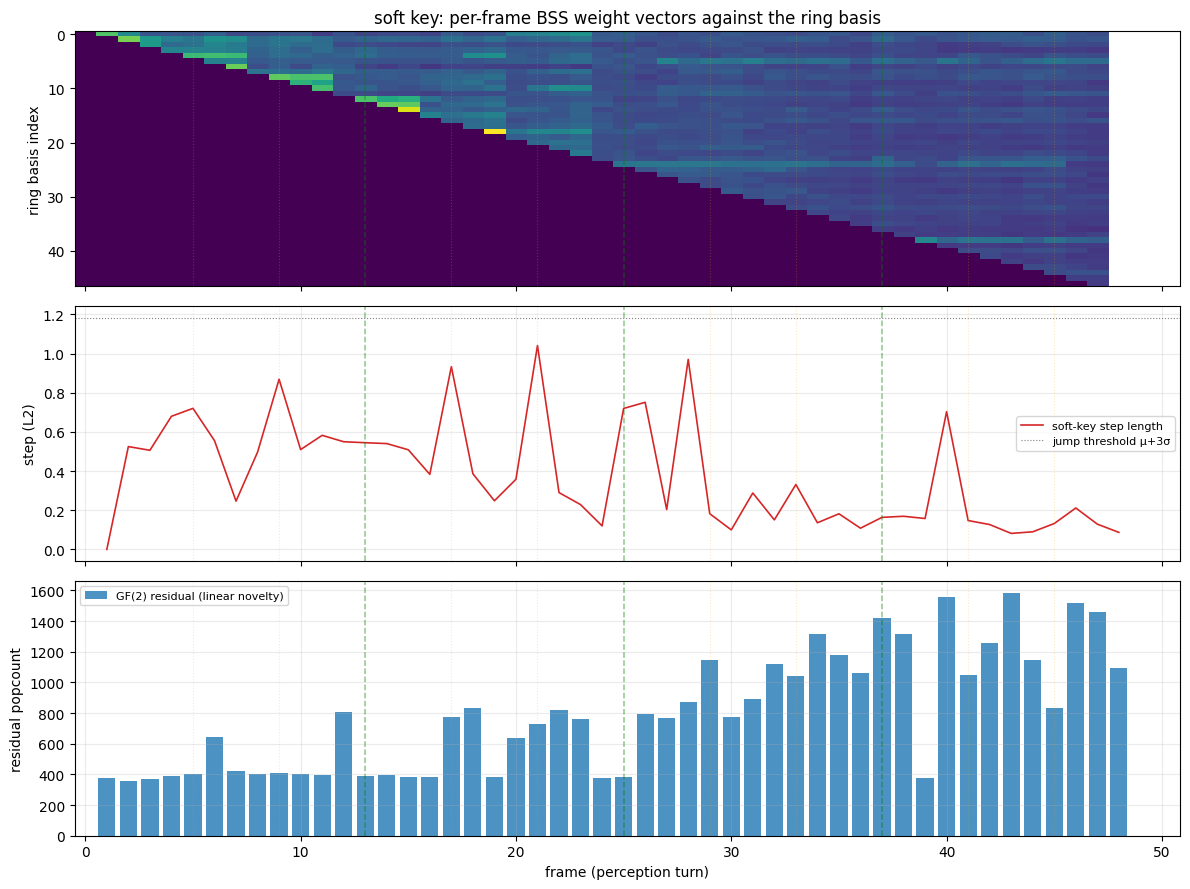

trajectory diagram saved to /home/alexmy/.cache/ewm-qwendrive/work/qwendrive_trajectory.png


In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

SCENE_CUTS = [13, 25, 37]          # frame 13 starts scene 1, etc.
VIEW_SWITCHES = [5, 9, 17, 21, 29, 33, 41, 45]

max_dim = max(len(f["soft"]) for f in sc["frames"])
Wmat = np.zeros((len(sc["frames"]), max_dim))
for i, f in enumerate(sc["frames"]):
    if f["soft"]:
        Wmat[i, :len(f["soft"])] = f["soft"]

steps = np.array([f["step"] for f in sc["frames"]], dtype=float)
residual = np.array([f["residual"] for f in sc["frames"]], dtype=float)
dim = np.array([f["dim"] for f in sc["frames"]], dtype=int)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].imshow(Wmat.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_ylabel("ring basis index")
axes[0].set_title("soft key: per-frame BSS weight vectors against the ring basis")

axes[1].plot(range(1, len(steps) + 1), steps, color="#d62728", lw=1.2,
             label="soft-key step length")
axes[1].axhline(sc["threshold"], color="gray", ls=":", lw=0.8,
                label="jump threshold μ+3σ")
for j in sc["jumps"]:
    axes[1].axvline(j, color="red", alpha=0.35, lw=1.2)
axes[1].set_ylabel("step (L2)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

axes[2].bar(range(1, len(residual) + 1), residual, color="tab:blue", alpha=0.8,
            label="GF(2) residual (linear novelty)")
axes[2].set_ylabel("residual popcount")
axes[2].set_xlabel("frame (perception turn)")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

for ax in axes:
    for c in SCENE_CUTS:
        ax.axvline(c, color="green", alpha=0.45, lw=1.1, ls="--")
    for v in VIEW_SWITCHES:
        ax.axvline(v, color="orange", alpha=0.25, lw=0.8, ls=":")
    ax.axvline(1, color="gray", alpha=0.0)  # keep axes aligned

plt.tight_layout()
plt.savefig(f"{WORK}/qwendrive_trajectory.png", dpi=110)
plt.show()
print("trajectory diagram saved to", f"{WORK}/qwendrive_trajectory.png")


---
## The BSS similarity vector as a signal — DFT over time

The growing-basis heatmap above is ragged (each row's soft key lengthens as
the basis grows). With `sidecar --freeze 12` the basis is fixed after the
first scene: for every later frame the denominators `|B_i|` are constants,
so the BSS vector is just the overlap-count vector up to a fixed scaling —
the snapshot map `S(t) → w(t) ∈ R^k` with **stable coordinates**. On that
fixed-dim time series the DFT over `t` is the Fourier route to the same
"processes behind the snapshots" question: a spectral line is a periodic
process; broadband/step energy is aperiodic novelty.


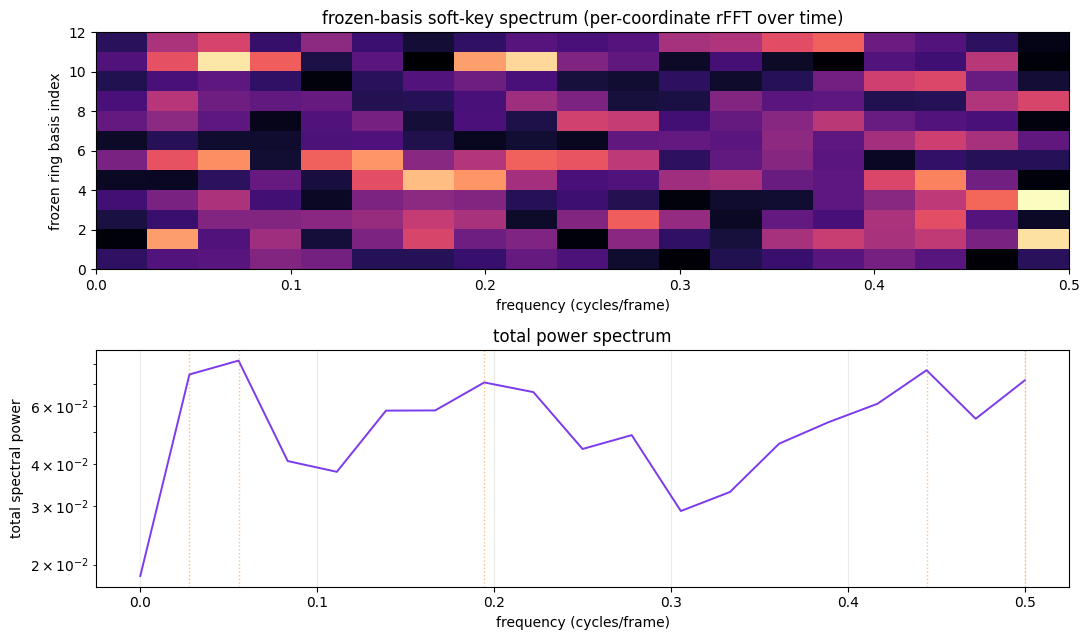

frozen basis dimension k: 12
stable-coordinate frames: 36 (frames 13 .. 48 )
dominant frequencies (cycles/frame): [0.056, 0.444, 0.028, 0.5, 0.194]
reference: multi-view cadence would appear at 1/3 ≈ 0.333
scene cuts are step-like aperiodic events, hence broadband — no single line
spectrum saved to /home/alexmy/.cache/ewm-qwendrive/work/qwendrive_spectrum.png


In [10]:
# ── DFT over the frozen-basis soft-key trajectory ───────────────────────────
freeze_n = 12
ff = sc_frozen["frames"]
Wf = np.array([f["soft"] for f in ff[freeze_n:]])     # frames 13..48, [36, k]
k = Wf.shape[1]
N = Wf.shape[0]
win = np.hanning(N)
Wc = (Wf - Wf.mean(axis=0, keepdims=True)) * win[:, None]
spec = np.abs(np.fft.rfft(Wc, axis=0))                # [N//2+1, k]
freqs = np.fft.rfftfreq(N, d=1.0)

power = (spec ** 2).sum(axis=1)                       # total power per frequency
top = np.argsort(power[1:])[::-1][:5] + 1
dominant = freqs[top]

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
axes[0].imshow(spec.T, aspect="auto", cmap="magma", interpolation="nearest",
               extent=[freqs[0], freqs[-1], 0, k])
axes[0].set_ylabel("frozen ring basis index")
axes[0].set_xlabel("frequency (cycles/frame)")
axes[0].set_title("frozen-basis soft-key spectrum (per-coordinate rFFT over time)")

axes[1].semilogy(freqs, power, color="#7c3aed", lw=1.4)
for f in dominant:
    axes[1].axvline(f, color="tab:orange", alpha=0.5, ls=":", lw=1.0)
axes[1].set_xlabel("frequency (cycles/frame)")
axes[1].set_ylabel("total spectral power")
axes[1].set_title("total power spectrum")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/qwendrive_spectrum.png", dpi=110)
plt.show()

print("frozen basis dimension k:", k)
print("stable-coordinate frames:", N, "(frames", freeze_n + 1, ".. 48 )")
print("dominant frequencies (cycles/frame):",
      [round(float(f), 3) for f in dominant])
print("reference: multi-view cadence would appear at 1/3 ≈ 0.333")
print("scene cuts are step-like aperiodic events, hence broadband — no single line")
print("spectrum saved to", f"{WORK}/qwendrive_spectrum.png")


In [11]:
# ── Cross-check: jump detector vs residual vs D/R/N at scene cuts ──────────
# The sidecar's generic jump detector is μ+3σ over all steps. For a fair
# scene-cut cross-check, the baselines below exclude the annotated cuts AND
# the multi-view switches, and use a 2σ threshold (the real-clip pattern of
# docs/BOOLRING.md).
SCENE_CUTS = [13, 25, 37]
VIEW_SWITCHES = [5, 9, 17, 21, 29, 33, 41, 45]
excl_frame = SCENE_CUTS + VIEW_SWITCHES
excl_pair = [i - 2 for i in excl_frame]   # pair i-1 -> i lives at 0-based i-2


def threshold_at(series, excl, k=2.0):
    base = np.delete(series, excl)
    return base.mean() + k * base.std()


steps = np.array([f["step"] for f in sc["frames"]], dtype=float)
res12 = np.array([f["residual"] for f in sc12["frames"]], dtype=float)
dp = np.array(noe["dp"], dtype=float)
rp = np.array(noe["rp"], dtype=float)
np_ = np.array(noe["np"], dtype=float)
dep = dp / (rp + np_ + 1e-9)

thr_step = threshold_at(steps, [i - 1 for i in excl_frame])
thr_res = threshold_at(res12, [i - 1 for i in excl_frame])
thr_dep = threshold_at(dep, excl_pair)

step_det = [c for c in SCENE_CUTS if steps[c - 1] > thr_step]
res_det = [c for c in SCENE_CUTS if res12[c - 1] > thr_res]
dep_det = [c for c in SCENE_CUTS if dep[c - 2] > thr_dep]

print("cross-check at scene cuts (baseline = in-scene transitions, 2σ):")
print("  soft-key step length   :", step_det, f"({len(step_det)}/{len(SCENE_CUTS)})")
print("  GF(2) residual (cap 12):", res_det, f"({len(res_det)}/{len(SCENE_CUTS)})")
print("  D/R/N departure ratio  :", dep_det, f"({len(dep_det)}/{len(SCENE_CUTS)})")
print("  steps at cuts:", [round(float(steps[c - 1]), 3) for c in SCENE_CUTS],
      "| threshold", round(float(thr_step), 3))
print("  D/R/N dep at cuts:", [round(float(dep[c - 2]), 3) for c in SCENE_CUTS],
      "| threshold", round(float(thr_dep), 3))
print()
print("The shared codebook lets scenes reuse tids, so the ring basis absorbs")
print("cut novelty (docs/BOOLRING.md real-clip note, stronger here). The D/R/N")
print("departure is the reliable cut line; the residual and the soft-key step")
print("are dominated by multi-view switches and in-scene variance.")


cross-check at scene cuts (baseline = in-scene transitions, 2σ):
  soft-key step length   : [] (0/3)
  GF(2) residual (cap 12): [] (0/3)
  D/R/N departure ratio  : [13, 25, 37] (3/3)
  steps at cuts: [0.545, 0.72, 0.164] | threshold 0.792
  D/R/N dep at cuts: [0.871, 0.85, 0.866] | threshold 0.846

The shared codebook lets scenes reuse tids, so the ring basis absorbs
cut novelty (docs/BOOLRING.md real-clip note, stronger here). The D/R/N
departure is the reliable cut line; the residual and the soft-key step
are dominated by multi-view switches and in-scene variance.


---
## Spectral PCA — frequency-local process modes

A single window's per-frequency cross-spectral matrix is rank-1 (one outer
product), which makes per-frequency PCA degenerate. The fix is the same as in
Welch's method: average the cross-spectral matrix over overlapping segments.
The top eigenvalue per frequency is then the power of the dominant *process
mode* at that frequency, and its eigenvector is the mode's loading pattern
over the frozen basis directions — the multivariate DFT, with the basis
directions as the "channels" of the signal.


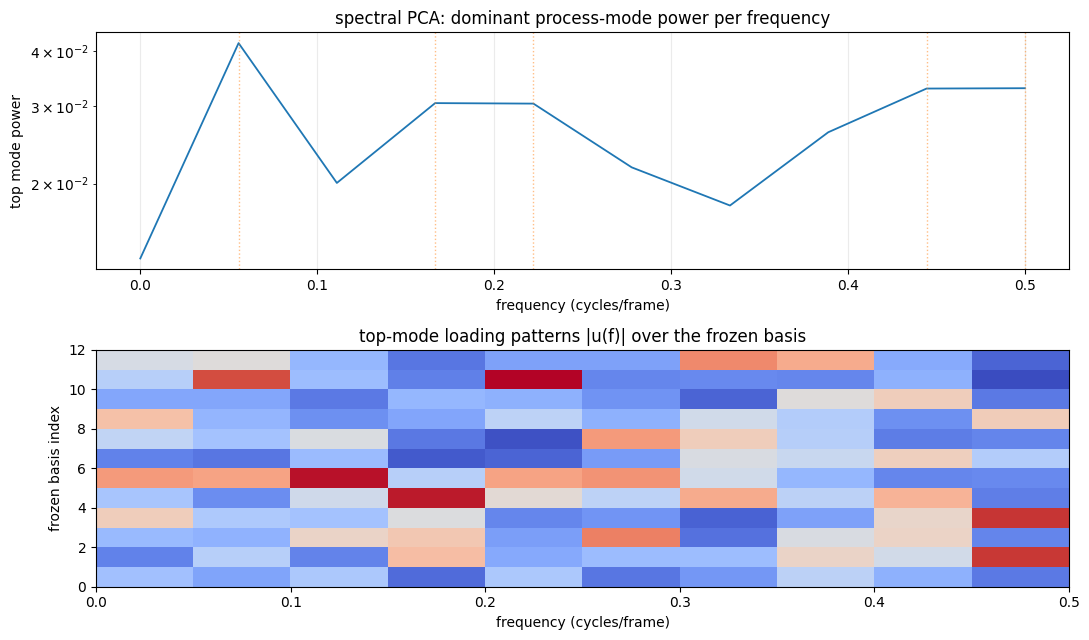

spectral PCA dominant modes (cycles/frame): [0.056, 0.5, 0.444, 0.167, 0.222]
  mode at 0.056: top basis loadings [1, 6, 0, 10]
  mode at 0.500: top basis loadings [8, 10, 3, 5]
  mode at 0.444: top basis loadings [7, 2, 5, 9]
saved /home/alexmy/.cache/ewm-qwendrive/work/qwendrive_spectral_pca.png


In [12]:
# ── Spectral PCA over the frozen-basis trajectory ───────────────────────────
# 3 overlapping segments of length 18 (hop 9) -> a rank-3 cross-spectral
# estimate per frequency, enough for a genuine (if short) spectral PCA.
seg_len, hop = 18, 9
segments = [Wc[s:s + seg_len] for s in range(0, N - seg_len + 1, hop)]
Fs = [np.fft.rfft(seg, axis=0) for seg in segments]      # each [10, k]
S = np.zeros((Fs[0].shape[0], k, k), dtype=np.complex128)
for Fseg in Fs:
    S += np.einsum("fi,fj->fij", Fseg, Fseg.conj())
S /= len(Fs)
freqs_seg = np.fft.rfftfreq(seg_len, d=1.0)

mode_power = np.zeros(S.shape[0])
mode_vecs = np.zeros((S.shape[0], k), dtype=np.complex128)
for f in range(S.shape[0]):
    w_, v = np.linalg.eigh(S[f])                         # ascending
    mode_power[f] = w_[-1]
    mode_vecs[f] = v[:, -1]

top_modes = np.argsort(mode_power[1:])[::-1][:5] + 1

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
axes[0].semilogy(freqs_seg, mode_power, color="#1f77b4", lw=1.3)
for m in top_modes:
    axes[0].axvline(freqs_seg[m], color="tab:orange", alpha=0.5, ls=":", lw=1.0)
axes[0].set_xlabel("frequency (cycles/frame)")
axes[0].set_ylabel("top mode power")
axes[0].set_title("spectral PCA: dominant process-mode power per frequency")
axes[0].grid(alpha=0.25)

axes[1].imshow(np.abs(mode_vecs.T), aspect="auto", cmap="coolwarm",
               interpolation="nearest",
               extent=[freqs_seg[0], freqs_seg[-1], 0, k])
axes[1].set_xlabel("frequency (cycles/frame)")
axes[1].set_ylabel("frozen basis index")
axes[1].set_title("top-mode loading patterns |u(f)| over the frozen basis")

plt.tight_layout()
plt.savefig(f"{WORK}/qwendrive_spectral_pca.png", dpi=110)
plt.show()

print("spectral PCA dominant modes (cycles/frame):",
      [round(float(freqs_seg[m]), 3) for m in top_modes])
for m in top_modes[:3]:
    load = np.abs(mode_vecs[m])
    print(f"  mode at {freqs_seg[m]:.3f}: top basis loadings",
          np.argsort(load)[::-1][:4].tolist())
print("saved", f"{WORK}/qwendrive_spectral_pca.png")


---
## The side-car shift warning — restored v-tokens + a tangible D/R/N report

The side-car's job is exactly *not* to reconstruct the scene: it restores the
v-tokens exactly (loop accuracy 1.0) and **warns about dramatic shifts**. The
warning is the Fourier-domain novelty `N_F(t) = ||w(t) − w_low(t)||` — the
part of the frozen-basis trajectory that a slow-context low-pass cannot
explain — OR-ed with the frozen residual and the D/R/N departure, each at 2σ.
The package handed to the host decoder/actuator is `(restored v-tokens,
warning)`, and the warning itself is **tangible**: for every warned frame the
side-car restores the exact `(D, R, N)` encodings of the transition — the
departed, retained and new v-tokens that explain the warning in unambiguous
data.


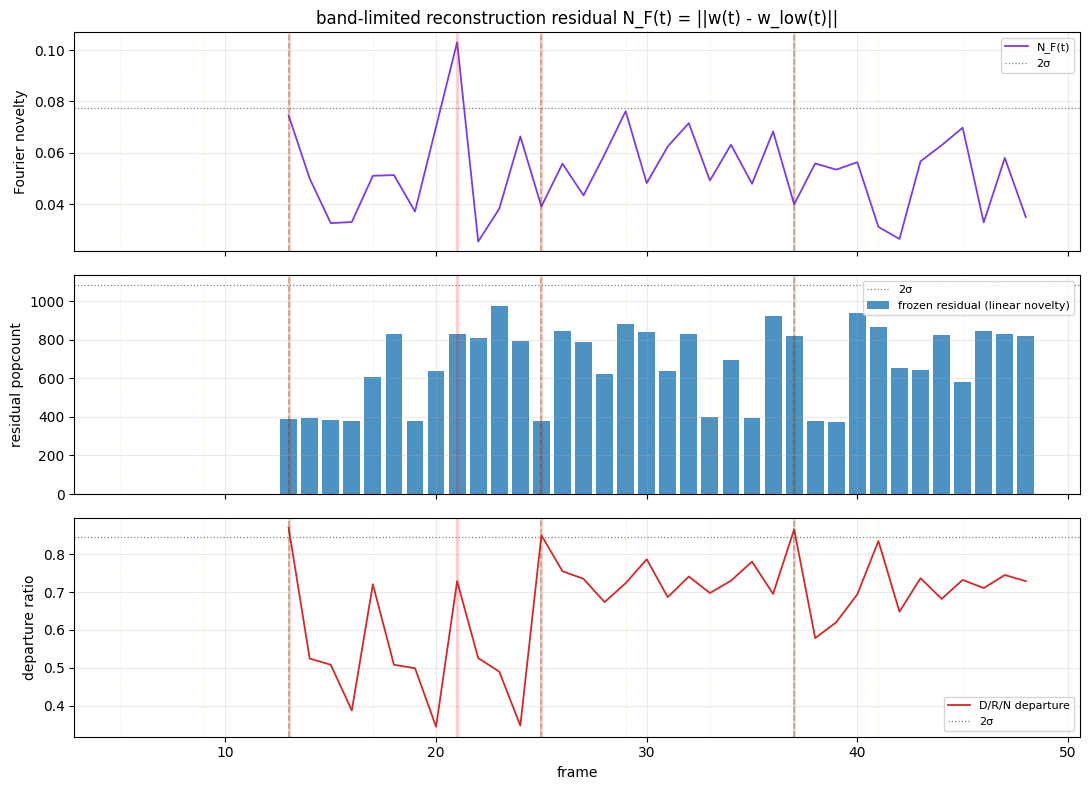

warned frames: [np.int64(13), np.int64(21), np.int64(25), np.int64(37)]
  scene cuts flagged:    [np.int64(13), np.int64(25), np.int64(37)] (3/3)
  view switches flagged: [np.int64(21)]
side-car hand-off (frames 13 .. 48, first 3): [{'frame': 13, 'restored_v_tokens': 156, 'warning': True, 'N_F': 0.075, 'departure': 0.871}, {'frame': 14, 'restored_v_tokens': 156, 'warning': False, 'N_F': 0.05, 'departure': 0.524}, {'frame': 15, 'restored_v_tokens': 156, 'warning': False, 'N_F': 0.033, 'departure': 0.508}]
decode agreement stays exact: 0.0 — the warning is the only thing the decoder must heed
saved /home/alexmy/.cache/ewm-qwendrive/work/qwendrive_warning.png
tangible warning report -> /home/alexmy/.cache/ewm-qwendrive/work/warning_report.json
  frame 13: D=130 R=16 N=124 | departure=0.871
  frame 21: D=106 R=33 N=103 | departure=0.729
  frame 25: D=125 R=17 N=119 | departure=0.85
  frame 37: D=114 R=23 N=102 | departure=0.866
  sample N encodings (frame 13 ): ['tid1030', 'tid1043', 'tid1

In [13]:
# ── Band-limited reconstruction: the Fourier-domain novelty N_F(t) ─────────
F_full = np.fft.rfft(Wf, axis=0)
F_lp = F_full.copy()
F_lp[freqs > 0.10] = 0.0                     # keep only the slow context
W_low = np.fft.irfft(F_lp, n=N, axis=0)
N_F = np.linalg.norm(Wf - W_low, axis=1)

# Frame-aligned companions (frames 13..48, 0-based 12..47):
#   frozen residual  — linear novelty vs the scene-0 basis
#   D/R/N departure — the transition into the frame
res_frozen = np.array([f["residual"] for f in ff[freeze_n:]], dtype=float)
dep_frame = dep[[t - 2 for t in range(freeze_n + 1, 49)]]

def zs(x):
    return (x - x.mean()) / (x.std() + 1e-12)

# Baselines exclude the annotated scene cuts and view switches, exactly like
# the cross-check above, so the 2σ thresholds sit on in-scene transitions.
excl_shift = [c for c in SCENE_CUTS + VIEW_SWITCHES if c >= freeze_n + 1]
base_mask = np.ones(len(t_axis := np.arange(freeze_n + 1, 49)), dtype=bool)
for c in excl_shift:
    base_mask[c - (freeze_n + 1)] = False

def th2(x):
    return x[base_mask].mean() + 2 * x[base_mask].std()

th_nf = th2(N_F)
th_res = th2(res_frozen)
# D/R/N baseline over the whole clip (all in-scene transitions, cuts and
# view switches excluded) — the frozen window alone has a noisier in-scene
# baseline and would inflate the threshold.
excl_pair = [i - 2 for i in SCENE_CUTS + VIEW_SWITCHES]
dep_base = np.delete(dep, excl_pair)
th_dep = dep_base.mean() + 2 * dep_base.std()
warn = (N_F > th_nf) | (res_frozen > th_res) | (dep_frame > th_dep)
warn_frames = [freeze_n + 1 + i for i in np.where(warn)[0]]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(t_axis, N_F, color="#7c3aed", lw=1.3, label="N_F(t)")
axes[0].axhline(th_nf, color="gray", ls=":", lw=0.9, label="2σ")
axes[0].set_ylabel("Fourier novelty")
axes[0].set_title("band-limited reconstruction residual N_F(t) = ||w(t) - w_low(t)||")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

axes[1].bar(t_axis, res_frozen, color="tab:blue", alpha=0.8,
            label="frozen residual (linear novelty)")
axes[1].axhline(th_res, color="gray", ls=":", lw=0.9, label="2σ")
axes[1].set_ylabel("residual popcount")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)

axes[2].plot(t_axis, dep_frame, color="#d62728", lw=1.3, label="D/R/N departure")
axes[2].axhline(th_dep, color="gray", ls=":", lw=0.9, label="2σ")
axes[2].set_xlabel("frame")
axes[2].set_ylabel("departure ratio")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.25)

for ax in axes:
    for c in SCENE_CUTS:
        ax.axvline(c, color="green", alpha=0.4, lw=1.1, ls="--")
    for v in VIEW_SWITCHES:
        ax.axvline(v, color="orange", alpha=0.22, lw=0.8, ls=":")
    for w in warn_frames:
        ax.axvline(w, color="red", alpha=0.18, lw=2.2)

plt.tight_layout()
plt.savefig(f"{WORK}/qwendrive_warning.png", dpi=110)
plt.show()

# ── The hand-off package: restored v-tokens + warning ──────────────────────
print("warned frames:", warn_frames)
print("  scene cuts flagged:   ", [f for f in warn_frames if f in SCENE_CUTS],
      f"({len([f for f in warn_frames if f in SCENE_CUTS])}/{len(SCENE_CUTS)})")
print("  view switches flagged:", [f for f in warn_frames if f in VIEW_SWITCHES])
handoff = [{
    "frame": int(t),
    "restored_v_tokens": len(restored_by_id[int(t)]),
    "warning": bool(warn[i]),
    "N_F": round(float(N_F[i]), 3),
    "departure": round(float(dep_frame[i]), 3),
} for i, t in enumerate(t_axis)]
print("side-car hand-off (frames", freeze_n + 1, ".. 48, first 3):", handoff[:3])
print("decode agreement stays exact:", round(float(np.mean(np.abs(P_orig - P_rest))), 6),
      "— the warning is the only thing the decoder must heed")
print("saved", f"{WORK}/qwendrive_warning.png")

# ── The tangible warning: exact D/R/N encodings per warned frame ───────────
# ewm-scene subframes restores the departed / retained / new v-token sets of
# the transition into the warned frame (1x156 grid = one perception frame).
GRID_JSONL = f"{WORK}/perception_frames_grid.jsonl"
with open(FRAMES_JSONL) as fh, open(GRID_JSONL, "w") as gh:
    for line in fh:
        rec = json.loads(line)
        gh.write(json.dumps({"id": rec["id"], "width": 156, "height": 1,
                             "tokens": rec["tokens"]}) + "\n")

report = []
for t in warn_frames:
    sf = ewm_scene("subframes", GRID_JSONL,
                   "--i", str(int(t) - 1), "--j", str(int(t)))
    i = int(t) - (freeze_n + 1)
    report.append({
        "frame": int(t),
        "D_encodings": sf["departed"],
        "R_encodings": sf["retained"],
        "N_encodings": sf["new"],
        "N_F": round(float(N_F[i]), 3),
        "departure": round(float(dep_frame[i]), 3),
    })
with open(f"{WORK}/warning_report.json", "w") as fh:
    json.dump(report, fh, indent=2)

print("tangible warning report ->", f"{WORK}/warning_report.json")
for r in report:
    print(f"  frame {r['frame']}: D={len(r['D_encodings'])} "
          f"R={len(r['R_encodings'])} N={len(r['N_encodings'])} "
          f"| departure={r['departure']}")
print("  sample N encodings (frame", report[0]["frame"], "):",
      report[0]["N_encodings"][:5], "...")
print("  sample D encodings (frame", report[0]["frame"], "):",
      report[0]["D_encodings"][:5], "...")


---
## Summary (Phase 1)

- **Real Qwen-Drive perception tokens.** Each camera frame's VLM visual-token
  hidden states are extracted (156 × 2560 per frame), quantized with the shared
  4096-anchor codebook, and ingested as one `tid{n}` turn — 48 turns over the 4
  bundled driving scenes.
- **The side-car loop closes exactly.** Hash-level restoration is 1.0 (set
  recall/precision) and ordered materialize is 1.0 (positional accuracy) —
  the encodings go back to the host in their original order.
- **Two scores, separate.** Loop accuracy (the morphism) is 1.0; decode
  quality (the host decoder) is measured as the waypoint disagreement between
  the original and restored encodings (~0), with the probe's LOSO ADE and the
  real Qwen-Drive Planning Expert ADE as the driving-relevant quality anchors.
- **The trajectory.** The per-frame soft key against the ring basis, its step
  lengths and the μ+3σ jump detector, cross-checked with the GF(2) residual
  (linear novelty, scene-bounded cap-12 window) and D/R/N. With the shared
  codebook the D/R/N departure is the reliable scene-cut line (3/3); the
  residual and the soft-key step are dominated by multi-view switches and
  in-scene variance — the real-clip pattern of docs/BOOLRING.md.
- **Frozen basis → DFT.** `sidecar --freeze 12` pins the basis, giving the
  stable snapshot map `S(t) → w(t) ∈ R^k`; the per-coordinate rFFT and the
  segment-averaged spectral PCA decompose it into frequency-local process
  modes (the multivariate DFT).
- **Shift warning.** Band-limited reconstruction gives the Fourier-domain
  novelty `N_F(t) = ||w(t) − w_low(t)||`; OR-ed with the frozen residual and
  the D/R/N departure at 2σ it forms the side-car's warning. The hand-off to
  the host decoder/actuator is `(restored v-tokens, warning)` — restoration
  stays exact (1.0) — and the warning is **tangible**: for each warned frame
  the side-car restores the exact `(D, R, N)` v-token sets that explain it
  (`warning_report.json`).


## New in this revision — time travel through the first interpretation

`sidecar` now returns `basis_history` (one entry per generation change) and, for every frame, `soft_first` / `spill_first`: the frame projected into the **first** recorded basis. The spill is how much of the present the past cannot see (docs/BASIS_FRAMES.md).

basis generations (gen, dim, cover_pop): [(1, 1, 379), (2, 2, 735), (3, 3, 1103), (4, 4, 1493), (5, 5, 1895), (6, 6, 2541), (7, 7, 2961), (8, 8, 3339), (9, 9, 3747), (10, 10, 4150), (11, 11, 4543), (12, 12, 5809), (13, 13, 6196), (14, 14, 6589), (15, 15, 6975), (16, 16, 7725), (17, 17, 9795), (18, 18, 11364), (19, 19, 11736), (20, 20, 11736), (21, 21, 12622), (22, 22, 13631), (23, 23, 14395), (24, 24, 17157), (25, 25, 17538), (26, 26, 18329), (27, 27, 19663), (28, 28, 20532), (29, 29, 21680), (30, 30, 22536), (31, 31, 23426), (32, 32, 28731), (33, 33, 30038), (34, 34, 33000), (35, 35, 34177), (36, 36, 35235), (37, 37, 36652), (38, 38, 38296), (39, 39, 38670), (40, 40, 41700), (41, 41, 42746), (42, 42, 44061), (43, 43, 46268), (44, 44, 47412), (45, 45, 48455), (46, 46, 50816), (47, 47, 57999), (48, 48, 59564)]
last frame in the first basis: soft = [0.166] | spill = 306 bits


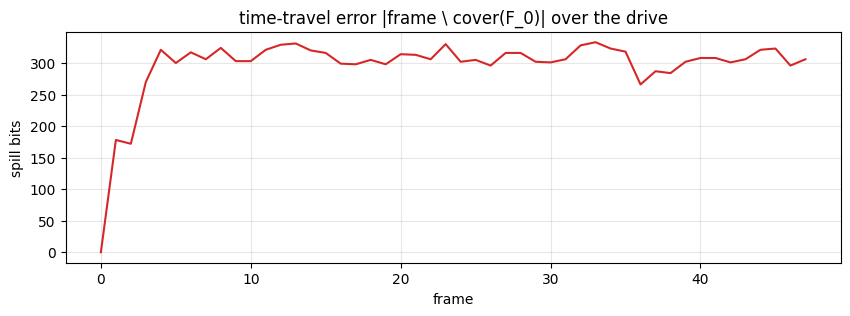

In [14]:
hist = sc["basis_history"]
frames = sc["frames"]
print("basis generations (gen, dim, cover_pop):",
      [(h["generation"], h["dimension"], h["cover_pop"]) for h in hist])

spill = [f["spill_first"] for f in frames]
last = frames[-1]
print("last frame in the first basis:",
      "soft =", [round(w, 3) for w in last["soft_first"]],
      "| spill =", last["spill_first"], "bits")

plt.figure(figsize=(10, 3))
plt.plot(spill, color="tab:red")
plt.title("time-travel error |frame \\ cover(F_0)| over the drive")
plt.xlabel("frame"); plt.ylabel("spill bits")
plt.grid(alpha=0.3)
plt.show()
